In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='QSO+LRG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

79651 14100
14530
10113
10113 10113
FIBERSTATUS 8364 1749 0.1729457134381489
No data 8364 0 0.0
5942 2422 0.7104256336681014
5942 5942


In [4]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep']], keys='TARGETID')

tileid_list = np.unique(zbest['TILEID'])

198699 14100
80626 5942


In [5]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,DELTA_X,DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,elgqso_weight,FIELD,TARGETS,SPECMODEL_SKY_RMAG_AB,HASGFA,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,Z_deep,ZWARN_deep,DELTACHI2_deep,B_DEPTH_deep,R_DEPTH_deep,Z_DEPTH_deep,B_DEPTH_EBVAIR_deep,R_DEPTH_EBVAIR_deep,Z_DEPTH_EBVAIR_deep
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,float64,float64,float64,float64,float64,str10,str7,float32,bool,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int64,float64,float64,float64,float64,float64,float64,float64
39627805352265275,8915.699081657454,473.33689803974954 .. 4.099613333095931,0.38714468894833365,0.0001238143655835395,0,7826,GALAXY,,10,776.775258326903,0,1,1,485,1485,666,0,149.31702367611464,0.8448453052364348,0.0,0.0,2020.9487,5400.0,1152921504707510369,1,TGT,203.78088,-344.5449,0,3200,0.6554448879017679,5,DEV,2.8328052,15.289917,34.912575,854.51764,249.38046,64.94606,0,,0.0,0.0,0.0,0.0,0.023,62.81794,38.44772,1.525466,8.233623,18.800426,1.5254711,8.233633,18.800453,0,4.0,0.51233107,0.121759854,-0.35520807,S,1152921504707510369,131074,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,203.715,-344.427,-0.005,-0.003,149.31704343778486,0.8448334601186536,20201215,68063,59199.50455879,80609,324.8830233514309,5901.6265869140625,32.82942450046539,41.46331238746643,1.0,COSMOS,QSO+LRG,21.316456,True,515.6,420.1,417.7,422.9307,370.56876,389.49176,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,4199,800,162,10,2125,1317,1341,395,207,150.12,2.206,900.0,59199.504,1.1619775,0.045501556,138.59363,137.41573,0.98538613,1.3731751,19.911888,0.41571525,0.32178935,0.40964004,6.8307137,4.9390993,0.114,1.4107234,0.38723480453295644,0,14951.379413604736,10984.599914550781,7969.700042724609,7215.700103759766,8965.964721679688,7011.713165283203,6717.894836425781


In [6]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [7]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']


# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # if '/south/sweep/' in sweep_fn:
    #     pz['field'] = 'south'
    # else:
    #     pz['field'] = 'north'
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(zbest['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(zbest), len(idx1), len(zbest)-len(idx1))
# zbest = zbest[idx1]
# ls = ls[idx2]

zbest = join(zbest, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

10
80626 5942


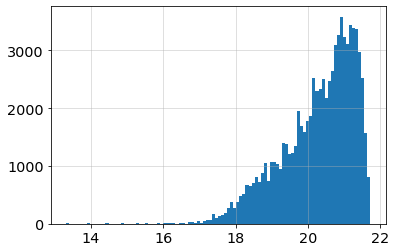

In [8]:
plt.hist(zbest['zmag'], 100)
plt.grid(alpha=0.5)
plt.show()

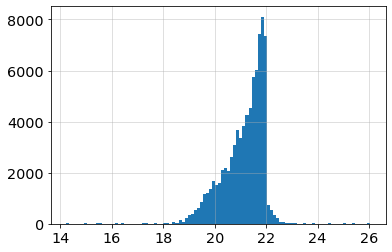

In [9]:
plt.hist(zbest['zfibermag'], 100)
plt.grid(alpha=0.5)
plt.show()

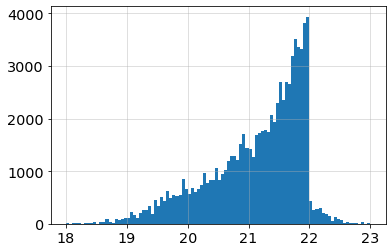

In [10]:
plt.hist(zbest['zfibermag'], 100, range=(18, 23))
plt.grid(alpha=0.5)
plt.show()

__In bins of zfibermag__

In [11]:
# stats = Table.read('/global/cfs/cdirs/desi/survey/observations/SV1/sv1-exposures.fits')
stats = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/sv1-exposures_20210210.fits')
print(len(stats))

mask = np.in1d(stats['EXPID'], np.unique(zbest['EXPID']))
stats = stats[mask]
print(len(stats))

stats['fail_frac_lrg_sv'] = -1.
stats['fail_frac_lrg_opt'] = -1.
stats['fail_frac_lrg_ir'] = -1.

stats['n_lrg_sv'] = -1
stats['n_lrg_opt'] = -1
stats['n_lrg_ir'] = -1

974
54


In [21]:
zfibermag_list = [21.0, 21.1, 21.2, 21.3, 21.4, 21.5, 21.6, 21.7, 21.8, 21.9, 22.0, 22.5]

from matplotlib.backends.backend_pdf import PdfPages
pdf_sv = PdfPages('/global/u2/r/rongpu/temp/sv1_lrg_failure_rate_in_zfiber_bins-sv.pdf')
pdf_opt = PdfPages('/global/u2/r/rongpu/temp/sv1_lrg_failure_rate_in_zfiber_bins-opt.pdf')
pdf_ir = PdfPages('/global/u2/r/rongpu/temp/sv1_lrg_failure_rate_in_zfiber_bins-ir.pdf')

for zfiber_index in range(len(zfibermag_list)-1):

    zfibermin, zfibermax = zfibermag_list[zfiber_index], zfibermag_list[zfiber_index+1]

    mask_mag = (zbest['zfibermag']>zfibermin) & (zbest['zfibermag']<zfibermax)

    mask_fiber = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)
    mask_fiber &= mask_mag

    fail_threshold = 0.0033
    mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > fail_threshold
    lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
    lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0

    for tileid in tileid_list:

        expid_list = np.array(np.unique(zbest['EXPID']))


        for expid in expid_list:

            stats_index = np.where(stats['EXPID']==expid)[0][0]

            mask_exp = mask_fiber & (zbest['EXPID']==expid)
            mask_exp_fail = mask_exp & mask_fail

            stats['fail_frac_lrg_sv'][stats_index] = np.sum(mask_exp_fail) / np.sum(mask_exp)
            stats['fail_frac_lrg_opt'][stats_index] = np.sum(mask_exp_fail & lrg_opt) / np.sum(mask_exp & lrg_opt)
            stats['fail_frac_lrg_ir'][stats_index] = np.sum(mask_exp_fail & lrg_ir) / np.sum(mask_exp & lrg_ir)        
            stats['n_lrg_sv'][stats_index] = np.sum(mask_exp)
            stats['n_lrg_opt'][stats_index] = np.sum(mask_exp & lrg_opt)
            stats['n_lrg_ir'][stats_index] = np.sum(mask_exp & lrg_ir)

    plt.figure(figsize=(8, 6))
    for tileid in tileid_list:
        mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
        n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
        p1 = np.maximum(p, 1/n)  # error floor
        errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
        plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                     yerr=(np.clip(errors, None, p), errors),
                     fmt='.', label=tileid)
    plt.xlabel('R_DEPTH_EBVAIR')
    plt.ylabel('Failure fraction')
    plt.grid(alpha=0.5)
    plt.legend(loc='upper right')
    plt.title('SV LRGs {:g} < zfiber < {:g}'.format(zfibermin, zfibermax))
    plt.ylim(-0.02, 0.5)
    pdf_sv.savefig()
    plt.close()
    
    if zfibermin<21.5:

        plt.figure(figsize=(8, 6))
        for tileid in tileid_list:
            mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
            n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
            p1 = np.maximum(p, 1/n)  # error floor
            errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
            plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                         yerr=(np.clip(errors, None, p), errors),
                         fmt='.', label=tileid)
        plt.xlabel('R_DEPTH_EBVAIR')
        plt.ylabel('Failure fraction')
        plt.grid(alpha=0.5)
        plt.legend(loc='upper right')
        plt.title('Baseline optical LRGs {:g} < zfiber < {:g}'.format(zfibermin, zfibermax))
        plt.ylim(-0.02, 0.5)
        pdf_opt.savefig()
        plt.close()

        plt.figure(figsize=(8, 6))
        for tileid in tileid_list:
            mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
            n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
            p1 = np.maximum(p, 1/n)  # error floor
            errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
            plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                         yerr=(np.clip(errors, None, p), errors),
                         fmt='.', label=tileid)
        plt.xlabel('R_DEPTH_EBVAIR')
        plt.ylabel('Failure fraction')
        plt.grid(alpha=0.5)
        plt.legend(loc='upper right')
        plt.title('Baseline IR LRGs {:g} < zfiber < {:g}'.format(zfibermin, zfibermax))
        plt.ylim(-0.02, 0.5)
        pdf_ir.savefig()
        plt.close()

pdf_sv.close()
pdf_opt.close()
pdf_ir.close()

<ipython-input-21-d33390d333a6>:35: RuntimeWarning: invalid value encountered in long_scalars
  stats['fail_frac_lrg_opt'][stats_index] = np.sum(mask_exp_fail & lrg_opt) / np.sum(mask_exp & lrg_opt)
<ipython-input-21-d33390d333a6>:36: RuntimeWarning: invalid value encountered in long_scalars
  stats['fail_frac_lrg_ir'][stats_index] = np.sum(mask_exp_fail & lrg_ir) / np.sum(mask_exp & lrg_ir)
